In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/Iris.csv')
print("Dataset prev")
print(df.head())
print("\nDataset Info")
print(df.info)


Dataset prev
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Info
<bound method DataFrame.info of       Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...       

2.2.1 Data Pre – processing.

In [ ]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
one_hot_encoder = OneHotEncoder(sparse_output=False)
y_one_hot = one_hot_encoder.fit_transform(y_encoded.reshape(-1, 1))
#display results
print("\n Unique Classes" , np.unique(y))
print("\n Encoded Labels", np.unique(y_encoded))
print("\n One-Hot Encoded Labels")
print(y_one_hot[:5])



 Unique Classes ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

 Encoded Labels [0 1 2]

 One-Hot Encoded Labels
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


2.2.1 Data Pre – processing.

In [ ]:
X_train ,X_test , y_train,y_test = train_test_split(X,y_one_hot,
  test_size=0.2,random_state=42,stratify=y_one_hot)
print("X_train shape",X_train.shape, "y_train shape",y_train.shape)
print("X_test shape",X_test.shape  , "y_test shape",y_test.shape )



X_train shape (120, 5) y_train shape (120, 3)
X_test shape (30, 5) y_test shape (30, 3)


2.3 Softmax Regression as Learning Function

In [ ]:
import numpy as np
def softmax(z):
  z_shifted = z - np.max(z,axis=1,keepdims=True)
  exp_z =np.exp(z_shifted)
  return exp_z / np.sum(exp_z,axis=1,keepdims=True)

2.4.1 Implementations – Loss Function

In [ ]:
def loss_softmax(y_pred,y):
  epsilon = 1e-12
  y_pred = np.clip(y_pred,epsilon,1-epsilon)
  n = y.shape[0]
  loss = -np.sum(y * np.log(y_pred)) / n
  return loss


2.4.2 Implementations – Cost Function

In [ ]:
def cost_softmax(X,y,W,b):
  n = X.shape[0]
  y_pred = softmax(np.dot(X,W) + b)
  z =np.dot(X,W) + b
  loss = loss_softmax(y_pred,y )
  cost = loss_softmax(y_pred,y)
  return cost

2.6.1.1 Implementations – Computing Gradients.

In [ ]:
def compute_gradient_softmax(X,y,W,b):
  n , d = X.shape
  z = np.dot(X,W) + b
  y_pred = softmax(z)
  grad_W = np.dot(X.T,(y_pred - y)) / n
  grad_b = np.sum(y_pred - y,axis=0) / n
  return grad_W,grad_b

2.6.2 Implementing Gradient Descent.

In [ ]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Perform gradient descent to optimize the weights and biases.

    Parameters:
    X (numpy.ndarray): Feature matrix of shape (n, d).
    y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c).
    W (numpy.ndarray): Weight matrix of shape (d, c).
    b (numpy.ndarray): Bias vector of shape (c,).
    alpha (float): Learning rate.
    n_iter (int): Number of iterations.
    show_cost (bool): Whether to display the cost at intervals.

    Returns:
    tuple: Optimized weights, biases, and cost history.
    """
    cost_history = []

    for i in range(n_iter):

        # Compute gradients
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # Update weights and biases using the gradients
        W -= alpha * grad_W
        b -= alpha * grad_b

        # Compute and store cost
        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)

        # Print cost at regular intervals
        if show_cost and (i % 100 == 0 or i == n_iter - 1):
            print(f"Iteration {i}: Cost = {cost:.6f}")

    return W, b, cost_history

In [ ]:
def predict_softmax(X, W, b):
    """
    Predict the class labels for a set of samples using the trained softmax model.

    Parameters
    X (numpy.ndarray): Feature matrix of shape (n, d), where n is the number of samples and d is the number of features.
    W (numpy.ndarray): Weight matrix of shape (d, c), where c is the number of classes.
    b (numpy.ndarray): Bias vector of shape (c,).

    Returns:
    numpy.ndarray: Predicted class labels of shape (n,), where each value is the index of the predicted class.
    """

    z = np.dot(X, W) + b  # Compute the scores (logits)
    y_pred = softmax(z)   # Get the probabilities using the softmax function

    # Assign the class with the highest probability
    predicted_classes = np.argmax(y_pred, axis=1)

    return predicted_classes

Iteration 0: Cost = 17.360593
Iteration 100: Cost = 16.409588
Iteration 200: Cost = 12.011365
Iteration 300: Cost = 13.643660
Iteration 400: Cost = 10.961685
Iteration 500: Cost = 3.743064
Iteration 600: Cost = 11.376998
Iteration 700: Cost = 10.039519
Iteration 800: Cost = 5.351736
Iteration 900: Cost = 14.038315
Iteration 999: Cost = 11.480766


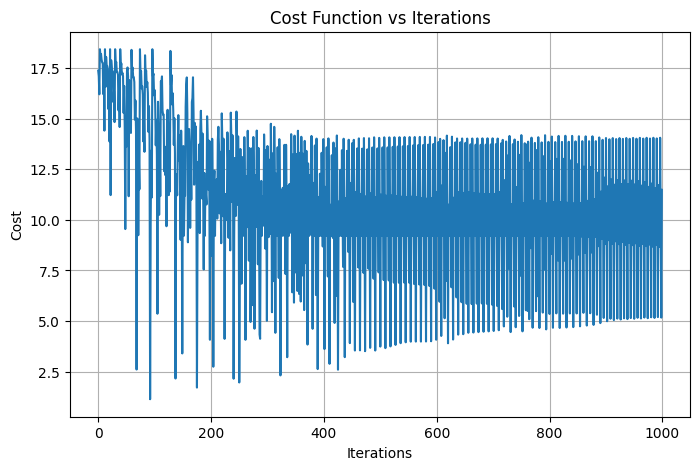

In [ ]:
# Initialize the weights and biases
d = X_train.shape[1]          # Number of features
c = y_train.shape[1]          # Number of classes

W = np.random.randn(d, c) * 0.01   # Small random weights
b = np.zeros((1, c))               # Bias as row vector

# Set hyperparameters
alpha = 0.1        # Learning rate
n_iter = 1000      # Number of iterations

# Train the model using gradient descent
W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b, alpha, n_iter, show_cost=True
)

# Plot the cost history to visualize convergence
plt.figure(figsize=(8, 5))
plt.plot(cost_history)
plt.title("Cost Function vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.grid(True)
plt.show()

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Evaluation Function
def evaluate_classification(y_true, y_pred):
    """
    Evaluate classification performance using confusion matrix, precision, recall, and F1-score.

    Parameters:
    y_true (numpy.ndarray): True labels
    y_pred (numpy.ndarray): Predicted labels

    Returns:
    tuple: Confusion matrix, precision, recall, F1 score
    """

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Compute precision, recall, and F1-score
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    return cm, precision, recall, f1

In [56]:
# Predict on the test set
y_pred_test = predict_softmax(X_test, W_opt, b_opt)

# Evaluate accuracy
y_test_labels = np.argmax(y_test, axis=1)  # True labels in numeric form

# Evaluate the model
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

# Print the evaluation metrics
print("\nConfusion Matrix:")
print(cm)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")


Confusion Matrix:
[[ 5  5  0]
 [ 0 10  0]
 [ 0  8  2]]
Precision: 0.81
Recall: 0.57
F1-Score: 0.54
